In [30]:
p = 90
N = 30
CIRCLES_SCALER = 1

# Batch sizes for comparison
BATCH_SIZES = {
    "conservative": [12, 24, 48],
    "physbo": [1]
}
trial_list = [1, 2, 3, 4, 5]

In [31]:
import pickle

import networkx as nx
import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 15
import numpy as np

from collections import defaultdict
from pathlib import Path
from sklearn.metrics.pairwise import pairwise_distances
from tqdm.asyncio import tqdm
from string import Template
from joblib import Parallel, delayed
from descriptor import Desctiptor
des = Desctiptor()

def maximal_independent_set(D, t):
    adj_matrix = np.array(D <= t, dtype=int)
    np.fill_diagonal(adj_matrix, 0)
    G = nx.from_numpy_array(np.array(adj_matrix))
    return nx.maximal_independent_set(G)

def calc_circles(X, radius):
    X = np.array(X)
    # print(X.shape, radius)
    D = pairwise_distances(X, metric="euclidean")
    s = maximal_independent_set(D, radius)
    return len(s)

def get_circles(X, action_idx, threshold_list):
    """並列化されたバージョン - joblibのスレッド並列化を使用"""
    return Parallel(n_jobs=-1, backend='threading')(
        delayed(calc_circles)(X, action_idx, t) for t in threshold_list)

def get_circles_process_parallel(X, action_idx, threshold_list):
    """プロセス並列化バージョン（大きなデータセット用）"""
    return Parallel(n_jobs=-1)(delayed(calc_circles)(X, action_idx, t) for t in threshold_list)

def get_circles_sequential(X, action_idx, threshold_list):
    """元のシーケンシャルバージョン（比較用）"""
    return [calc_circles(X, action_idx, t) for t in threshold_list]

# Directory name's template string - 新しい命名規則
# data_{mode}_batch{batch_size}_trial{trial}
dir_template = Template("data_${MODE}_batch${BATCH_SIZE}_trial${TRIAL}")

radius_list = np.arange(0, 5.1, 0.1)

# 比較するメソッド・バッチの組み合わせ (label, mode, batch_size)
method_configs = [
    ("physbo (batch=1)", "physbo", 1),
    ("NTS conservative (batch=12)", "conservative", 12),
    ("NTS conservative (batch=24)", "conservative", 24),
    ("NTS conservative (batch=48)", "conservative", 48),
]

In [32]:
# データ構造の詳細調査と修正されたデータ読み込み


def collect_near_optimal_samples(samples_dict, objectives_dict, target_threshold, iter_num):
    """
    指定されたイテレーション数まで、target_thresholdを超えるサンプルを収集する関数
    
    Parameters:
    -----------
    samples_dict : dict
        各イテレーションのサンプルデータ
    objectives_dict : dict  
        各イテレーションの目的値データ
    target_threshold : float
        閾値
    iter_num : int
        処理するイテレーション数
    
    Returns:
    --------
    dict : 各イテレーションまでの累積near-optimalサンプル
    int : 見つかったnear-optimalサンプルの総数
    """
    near_optimal_samples_by_iter = defaultdict(list)
    # print(samples_dict.keys())
    for k in range(1, len(samples_dict.keys()) + 1):
        # near_optimal_samples_by_iter は各イテレーションまでに見つかったnear-optimal samplesを全て保持
        near_optimal_samples_by_iter[k] = near_optimal_samples_by_iter[k-1].copy()
        for sample, obj in zip(samples_dict[k], objectives_dict[k]):
            if obj >= target_threshold:
                near_optimal_samples_by_iter[k].append(sample)
    
    return near_optimal_samples_by_iter

def circles_by_radius(X, radius_list):
    return [calc_circles(X, r) for r in radius_list]

def all_circles(sample_path, objective_path, target_threshold, N):

    with open(sample_path, 'rb') as f:
        samples_dict = pickle.load(f)

    with open(objective_path, 'rb') as f:
        objectives_dict = pickle.load(f)


    # function = Descriptor()
    near_optimal_samples_by_iter = defaultdict(list)
    # kを1から10まで変化させ、target_thresholdを超えたサンプルを

    # 関数を使用
    near_optimal_samples_by_iter = collect_near_optimal_samples(
        samples_dict, objectives_dict, target_threshold, N
    )
    n = len(near_optimal_samples_by_iter)
    circles = circles_by_radius(near_optimal_samples_by_iter[n-1], radius_list)
    return circles

def all_max_objective(sample_path, objective_path, N):

    with open(sample_path, 'rb') as f:
        samples_dict = pickle.load(f)

    with open(objective_path, 'rb') as f:
        objectives_dict = pickle.load(f)

    max_objective_list = [max(objectives_dict[k]) for k in sorted(list(objectives_dict.keys()))]
    all_max_objective_list = [max_objective_list[0]]
    n = len(max_objective_list)
    for k in range(1, n):
        # print(max_objective_list, max(objectives_dict[k]))
        all_max_objective_list.append(max(all_max_objective_list[-1], max(objectives_dict[k])))
    return all_max_objective_list

# target_threshold は function.y の90パーセンタイルに対応
target_threshold = np.percentile(des.y, p)
print(f"Target threshold for {p}% percentile: {target_threshold}")

Target threshold for 90% percentile: 1.1465392917


In [33]:
# データ読み込み：各メソッド・バッチサイズ組み合わせについてCirclesを計算
method_to_circles = defaultdict(list)
method_to_batch_size = {}

for label, mode, batch_size in method_configs:
    method_to_batch_size[label] = batch_size
    for trial in trial_list:
        data_dir = dir_template.substitute(MODE=mode, BATCH_SIZE=batch_size, TRIAL=trial)
        sample_path = Path(data_dir) / "sample_by_iter.pkl"
        objective_path = Path(data_dir) / "objective_by_iter.pkl"
        
        if not sample_path.exists():
            print(f"Warning: {sample_path} not found, skipping...")
            continue
            
        circles = all_circles(sample_path, objective_path, target_threshold, N)
        method_to_circles[label].append([c / CIRCLES_SCALER for c in circles])

print("Data loading completed.")
for label in method_to_circles:
    print(f"  {label}: {len(method_to_circles[label])} trials loaded")

Data loading completed.
  physbo (batch=1): 5 trials loaded
  NTS conservative (batch=12): 5 trials loaded
  NTS conservative (batch=24): 5 trials loaded
  NTS conservative (batch=48): 5 trials loaded


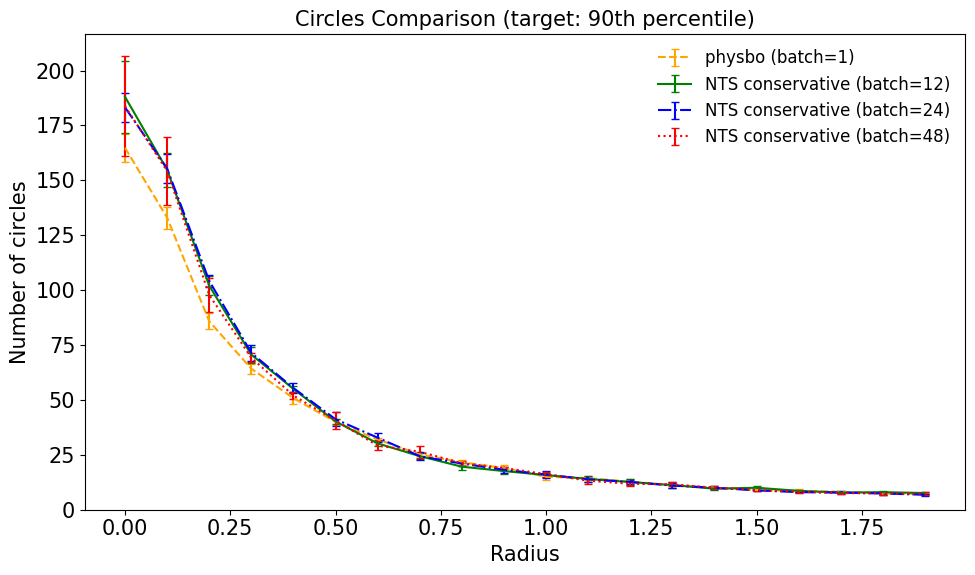

In [34]:
# スタイル設定
method_to_style = {
    "physbo (batch=1)": "--",
    "NTS conservative (batch=12)": "-",
    "NTS conservative (batch=24)": "-.",
    "NTS conservative (batch=48)": ":",
}

method_to_color = {
    "physbo (batch=1)": "orange",
    "NTS conservative (batch=12)": "green",
    "NTS conservative (batch=24)": "blue",
    "NTS conservative (batch=48)": "red",
}

# Circlesのプロット
fig, ax = plt.subplots(figsize=(10, 6))
for label in method_to_circles:
    if len(method_to_circles[label]) == 0:
        continue
    mean_circles = np.mean(np.array(method_to_circles[label]), axis=0)
    std_circles = np.std(np.array(method_to_circles[label]), axis=0)
    ax.errorbar(radius_list[:20], mean_circles[:20], yerr=std_circles[:20], 
                label=label, linestyle=method_to_style[label], 
                color=method_to_color[label], capsize=3)

ax.set_xlabel("Radius", fontsize=15)
ax.set_ylabel("Number of circles", fontsize=15)
ax.set_title(f"Circles Comparison (target: {p}th percentile)", fontsize=15)
ax.set_ylim(0)
ax.legend(fontsize=12, frameon=False)
plt.tight_layout()
plt.savefig(f"figures/circles_comparison_batch_sizes_{p}percentile.pdf")
plt.show()

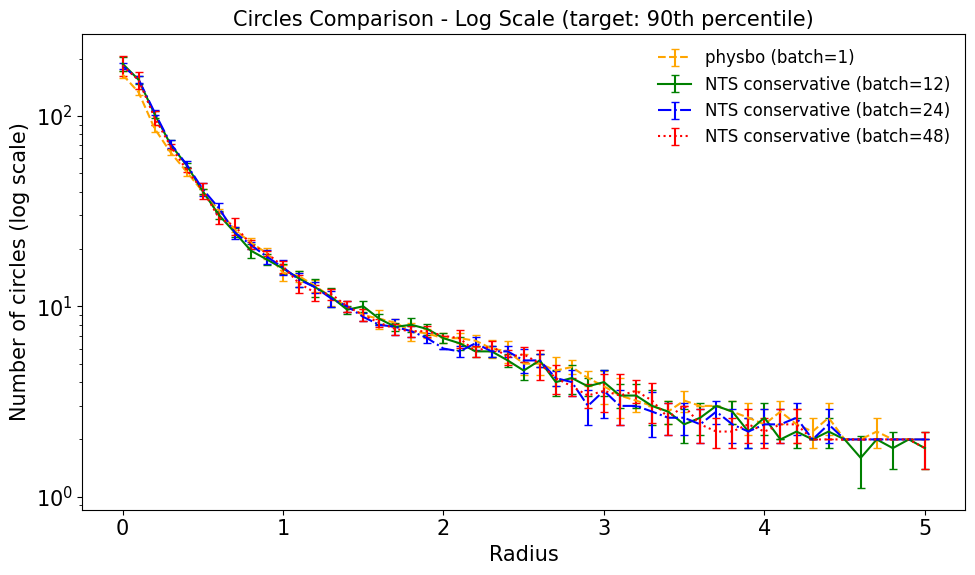

In [35]:
# Circles (log scale)
fig, ax = plt.subplots(figsize=(10, 6))
for label in method_to_circles:
    if len(method_to_circles[label]) == 0:
        continue
    mean_circles = np.mean(np.array(method_to_circles[label]), axis=0)
    std_circles = np.std(np.array(method_to_circles[label]), axis=0)
    ax.errorbar(radius_list, mean_circles, yerr=std_circles, 
                label=label, linestyle=method_to_style[label], 
                color=method_to_color[label], capsize=3)

ax.set_xlabel("Radius", fontsize=15)
ax.set_ylabel("Number of circles (log scale)", fontsize=15)
ax.set_title(f"Circles Comparison - Log Scale (target: {p}th percentile)", fontsize=15)
ax.set_yscale("log")
ax.legend(fontsize=12, frameon=False)
plt.tight_layout()
plt.savefig(f"figures/circles_comparison_batch_sizes_{p}percentile_log.pdf")
plt.show()

In [36]:
# Simple regretの計算
method_to_objectives = defaultdict(list)
method_to_regrets = defaultdict(list)

for label, mode, batch_size in method_configs:
    for trial in trial_list:
        data_dir = dir_template.substitute(MODE=mode, BATCH_SIZE=batch_size, TRIAL=trial)
        sample_path = Path(data_dir) / "sample_by_iter.pkl"
        objective_path = Path(data_dir) / "objective_by_iter.pkl"
        # with open(objective_path, 'rb') as f:
        #     objectives_dict = pickle.load(f)
        #     print(objectives_dict)
        
        if not sample_path.exists():
            continue
            
        objectives = all_max_objective(sample_path, objective_path, N)
        method_to_objectives[label].append(objectives)
        method_to_regrets[label].append([des.get_regret(obj) for obj in objectives])

print("Regret data loading completed.")

Regret data loading completed.


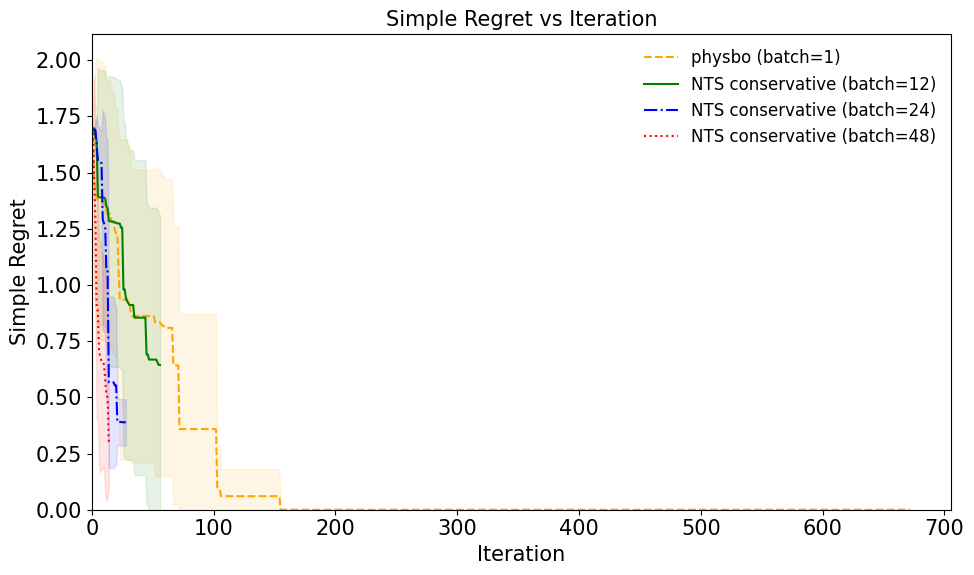

In [37]:
# Simple Regret vs Iteration
fig, ax = plt.subplots(figsize=(10, 6))
for label in method_to_regrets:
    if len(method_to_regrets[label]) == 0:
        print(label)
        continue
    # if label == "NTS conservative (batch=24)":
    #     continue
    mean_regrets = np.mean(np.array(method_to_regrets[label]), axis=0)
    std_regrets = np.std(np.array(method_to_regrets[label]), axis=0)
    iterations = np.arange(len(mean_regrets))
    ax.plot(iterations, mean_regrets, label=label, 
            linestyle=method_to_style[label], color=method_to_color[label])
    ax.fill_between(iterations, mean_regrets - std_regrets, 
                    mean_regrets + std_regrets, alpha=0.1, color=method_to_color[label])

ax.set_xlabel("Iteration", fontsize=15)
ax.set_ylabel("Simple Regret", fontsize=15)
ax.set_title("Simple Regret vs Iteration", fontsize=15)
ax.set_xlim(-0.1)
ax.set_ylim(0)
ax.legend(fontsize=12, frameon=False)
plt.tight_layout()
plt.savefig("figures/simple_regret_vs_iteration.pdf")
plt.show()

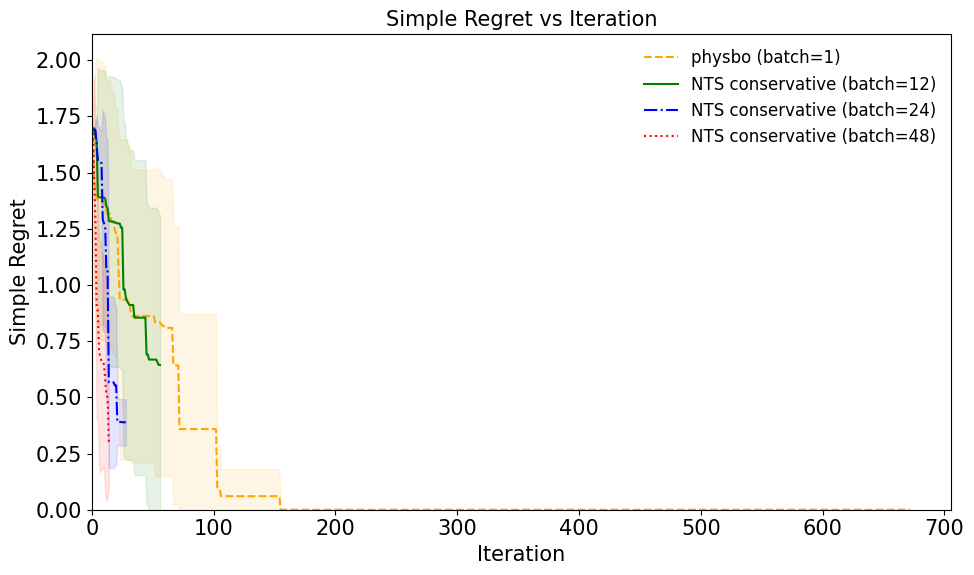

In [38]:
# Simple Regret vs Iteration
fig, ax = plt.subplots(figsize=(10, 6))
for label in method_to_regrets:
    if len(method_to_regrets[label]) == 0:
        continue
    # if label == "NTS conservative (batch=24)":
    #     continue
    mean_regrets = np.mean(np.array(method_to_regrets[label]), axis=0)
    std_regrets = np.std(np.array(method_to_regrets[label]), axis=0)
    iterations = np.arange(len(mean_regrets))
    ax.plot(iterations, mean_regrets, label=label, 
            linestyle=method_to_style[label], color=method_to_color[label])
    ax.fill_between(iterations, mean_regrets - std_regrets, 
                    mean_regrets + std_regrets, alpha=0.1, color=method_to_color[label])

ax.set_xlabel("Iteration", fontsize=15)
ax.set_ylabel("Simple Regret", fontsize=15)
ax.set_title("Simple Regret vs Iteration", fontsize=15)
ax.set_xlim(-0.1)
ax.set_ylim(0)
ax.legend(fontsize=12, frameon=False)
plt.tight_layout()
plt.savefig("figures/simple_regret_vs_iteration.pdf")
plt.show()

physbo (batch=1): expanded_regrets.shape = (5, 720)
NTS conservative (batch=12): expanded_regrets.shape = (5, 720)
NTS conservative (batch=24): expanded_regrets.shape = (5, 720)
NTS conservative (batch=48): expanded_regrets.shape = (5, 720)


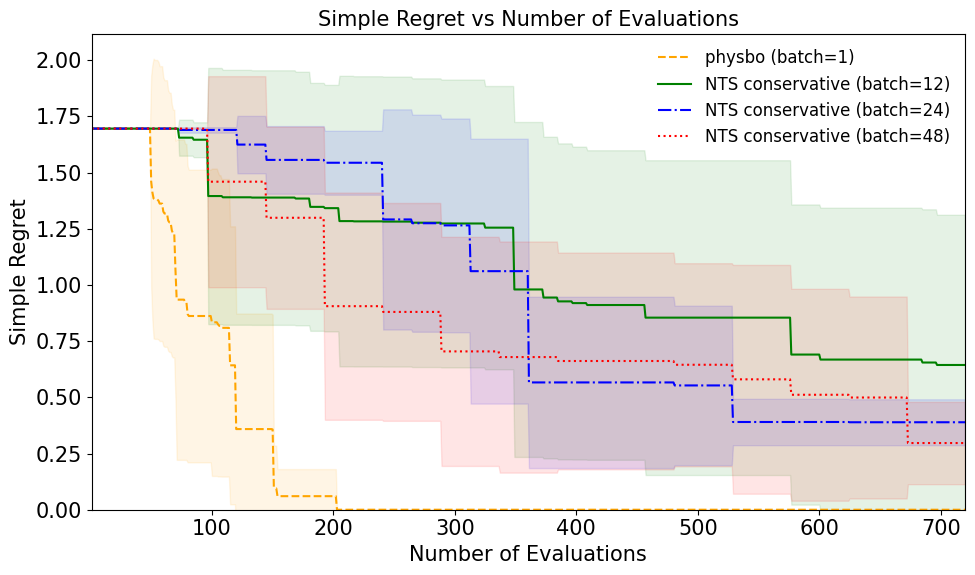

In [43]:
# Simple Regret vs Number of Evaluations (評価回数)
# 各バッチのregret値をバッチサイズ分繰り返して表示
INITIAL_BATCH_SIZE = 48

fig, ax = plt.subplots(figsize=(10, 6))

for label in method_to_regrets:
    if len(method_to_regrets[label]) == 0:
        continue
    batch_size = method_to_batch_size[label]
    regrets_array = np.array(method_to_regrets[label])  # shape: (trials, iterations)
    
    # 最初のregretだけはINITIAL_BATCH_SIZE回繰り返す
    first_regret = regrets_array[:, :1]  # shape: (trials, 1)
    initial_expanded = np.repeat(first_regret, INITIAL_BATCH_SIZE, axis=1)  # shape: (trials, 48)
    
    # 残りのregretはbatch_size回繰り返す
    remaining_regrets = regrets_array[:, 1:]  # shape: (trials, iterations-1)
    remaining_expanded = np.repeat(remaining_regrets, batch_size, axis=1)
    
    expanded_regrets = np.concatenate([initial_expanded, remaining_expanded], axis=1)
    print(f"{label}: expanded_regrets.shape = {expanded_regrets.shape}")
    
    mean_regrets = np.mean(expanded_regrets, axis=0)
    std_regrets = np.std(expanded_regrets, axis=0)
    
    # 評価回数 = 1, 2, 3, ...
    evaluations = np.arange(1, len(mean_regrets)+1)
    
    ax.plot(evaluations, mean_regrets, label=label, 
            linestyle=method_to_style[label], color=method_to_color[label])
    ax.fill_between(evaluations, mean_regrets - std_regrets, 
                    mean_regrets + std_regrets, alpha=0.1, color=method_to_color[label])

ax.set_xlabel("Number of Evaluations", fontsize=15)
ax.set_ylabel("Simple Regret", fontsize=15)
ax.set_title("Simple Regret vs Number of Evaluations", fontsize=15)
ax.set_ylim(0)
ax.set_xlim(1, 720)
ax.legend(fontsize=12, frameon=False)
plt.tight_layout()
plt.savefig("figures/simple_regret_vs_evaluations.pdf")
plt.show()

In [40]:
np.__version__

'2.4.2'

Circles AUC summary:
------------------------------------------------------------
physbo (batch=1): 76.78 ± 1.96
NTS conservative (batch=12): 81.63 ± 1.94
NTS conservative (batch=24): 81.94 ± 2.15
NTS conservative (batch=48): 80.76 ± 2.57


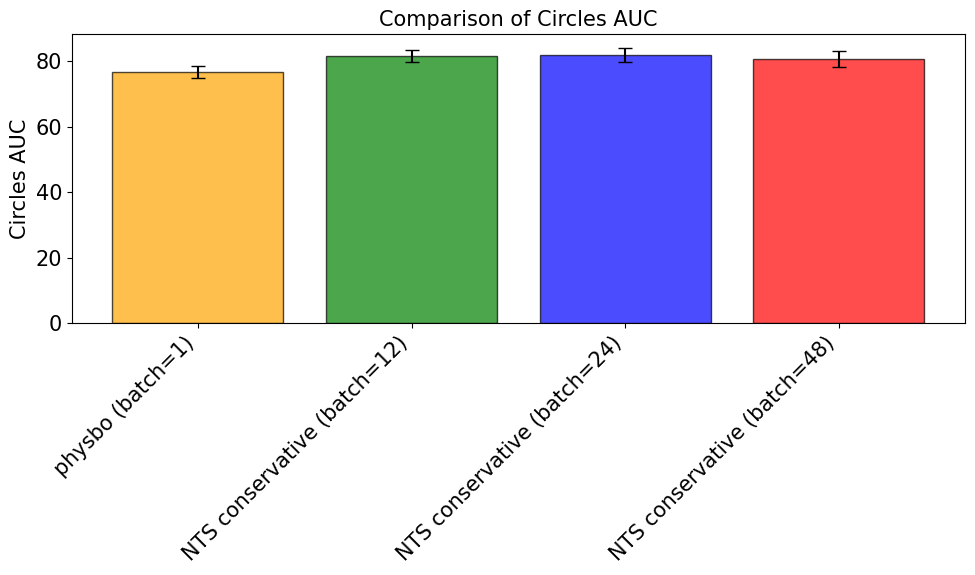

In [41]:
# Circles AUC (曲線下面積) の比較
trapz_dict = defaultdict(list)
for label in method_to_circles:
    if len(method_to_circles[label]) == 0:
        continue
    for circles in method_to_circles[label]:
        trapz_dict[label].append(np.trapezoid(circles, radius_list))

print("Circles AUC summary:")
print("-" * 60)
for label in trapz_dict:
    mean_val = np.mean(trapz_dict[label])
    std_val = np.std(trapz_dict[label])
    print(f"{label}: {mean_val:.2f} ± {std_val:.2f}")

# Bar plot
if len(trapz_dict) > 0:
    labels = list(trapz_dict.keys())
    means = [np.mean(trapz_dict[label]) for label in labels]
    stds = [np.std(trapz_dict[label]) for label in labels]
    colors = [method_to_color[label] for label in labels]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(range(len(labels)), means, yerr=stds, capsize=5, 
                  color=colors, alpha=0.7, edgecolor='black')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel("Circles AUC", fontsize=15)
    ax.set_title("Comparison of Circles AUC", fontsize=15)
    plt.tight_layout()
    plt.savefig("figures/circles_auc_comparison.pdf")
    plt.show()

In [42]:
# Summary statistics
print("=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"\nTarget threshold: {p}th percentile = {target_threshold:.4f}")
print(f"Number of iterations: {N}")
print(f"Number of trials per method: {len(trial_list)}")
print("\n")

print("Final Simple Regret (at last iteration):")
print("-" * 50)
for label in method_to_regrets:
    if len(method_to_regrets[label]) == 0:
        continue
    final_regrets = [r[-1] for r in method_to_regrets[label]]
    print(f"{label}: {np.mean(final_regrets):.4f} ± {np.std(final_regrets):.4f}")

SUMMARY

Target threshold: 90th percentile = 1.1465
Number of iterations: 30
Number of trials per method: 5


Final Simple Regret (at last iteration):
--------------------------------------------------
physbo (batch=1): 0.0000 ± 0.0000
NTS conservative (batch=12): 0.6441 ± 0.6684
NTS conservative (batch=24): 0.3892 ± 0.1022
NTS conservative (batch=48): 0.2967 ± 0.1831
